In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/transaction-data-for-banking-operations/transaction_data.csv


# **EDA on transaction_data**

In [2]:
df_transaction_data = pd.read_csv("/kaggle/input/transaction-data-for-banking-operations/transaction_data.csv")
df_transaction_data.head()

,Transaction ID,Sender Account ID,Receiver Account ID,Transaction Amount,Transaction Type,Timestamp,Transaction Status,Fraud Flag,Geolocation (Latitude/Longitude),Device Used,Network Slice ID,Latency (ms),Slice Bandwidth (Mbps),PIN Code
0,TXN9520068950,ACC14994,ACC16656,495.90,Deposit,2025-01-17 10:14:00,Failed,True,"34.0522 N, -74.006 W",Desktop,Slice3,10,179,3075
1,TXN9412011085,ACC58958,ACC32826,529.62,Withdrawal,2025-01-17 10:51:00,Success,False,"35.6895 N, -118.2437 W",Mobile,Slice2,11,89,2369
2,TXN4407425052,ACC56321,ACC92481,862.47,Withdrawal,2025-01-17 10:50:00,Failed,False,"48.8566 N, 2.3522 W",Mobile,Slice1,4,53,8039
3,TXN2214150284,ACC48650,ACC76457,1129.88,Transfer,2025-01-17 10:56:00,Success,True,"34.0522 N, -74.006 W",Mobile,Slice3,10,127,6374
4,TXN4247571145,ACC60921,ACC11419,933.24,Deposit,2025-01-17 10:25:00,Success,True,"55.7558 N, 37.6173 W",Mobile,Slice3,20,191,8375


In [3]:
df_transaction_data_column_names = df_transaction_data.columns
print(df_transaction_data_column_names)

Index(['Transaction ID', 'Sender Account ID', 'Receiver Account ID',
       'Transaction Amount', 'Transaction Type', 'Timestamp',
       'Transaction Status', 'Fraud Flag', 'Geolocation (Latitude/Longitude)',
       'Device Used', 'Network Slice ID', 'Latency (ms)',
       'Slice Bandwidth (Mbps)', 'PIN Code'],
      dtype='object')


In [4]:
df_transaction_data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction ID                    1000 non-null   object 
 1   Sender Account ID                 1000 non-null   object 
 2   Receiver Account ID               1000 non-null   object 
 3   Transaction Amount                1000 non-null   float64
 4   Transaction Type                  1000 non-null   object 
 5   Timestamp                         1000 non-null   object 
 6   Transaction Status                1000 non-null   object 
 7   Fraud Flag                        1000 non-null   bool   
 8   Geolocation (Latitude/Longitude)  1000 non-null   object 
 9   Device Used                       1000 non-null   object 
 10  Network Slice ID                  1000 non-null   object 
 11  Latency (ms)                      1000 non-null   int64  
 12  Slice B

In [5]:
# pip install -U pandasql
from pandasql import sqldf

# Define the pysqldf function as a lambda for executing SQL queries.
pysqldf = lambda q: sqldf(q)

pysqldf("""SELECT 
            COUNT(*) AS total_transaction, 
            ROUND(AVG(`Transaction Amount`), 2) AS mean_amount,
            MIN(`Transaction Amount`) AS min_amount,
            MAX(`Transaction Amount`) AS max_amount,
            MAX(`Transaction Amount`) - MIN(`Transaction Amount`) AS range_amount
        FROM df_transaction_data;""")

,total_transaction,mean_amount,min_amount,max_amount,range_amount
0,1000,771.17,51.89,1497.76,1445.87


In [6]:
# pip install -U pandasql
from pandasql import sqldf

# Define the pysqldf function as a lambda for executing SQL queries.
pysqldf = lambda q: sqldf(q)

pysqldf("""SELECT 
            DISTINCT `Transaction Type`, 
            COUNT(*) AS Number_of_Transactions, 
            `Fraud Flag`
            FROM df_transaction_data
            GROUP BY `Transaction Type`, `Fraud Flag`;
            """)

,Transaction Type,Number_of_Transactions,Fraud Flag
0,Deposit,149,0
1,Deposit,167,1
2,Transfer,204,0
3,Transfer,170,1
4,Withdrawal,166,0
5,Withdrawal,144,1


In [7]:
pysqldf("""SELECT 
                DISTINCT `Transaction Status` ,
                COUNT(*) AS Number_of_Transactions
            FROM df_transaction_data
            GROUP BY `Transaction Status`;
        """)

,Transaction Status,Number_of_Transactions
0,Failed,513
1,Success,487


In [8]:
pysqldf("""
SELECT
  ROUND(
    100.0 * SUM(CASE WHEN "Transaction Status" = 'Success' THEN 1 ELSE 0 END)
    / COUNT(DISTINCT "Transaction ID"),
    2
  ) AS successful_transaction_percentage
FROM df_transaction_data;
""")

,successful_transaction_percentage
0,48.7


In [9]:
pysqldf("""SELECT 
                DISTINCT `Fraud Flag`, 
                COUNT(*) AS Number_of_Transactions
            FROM df_transaction_data
            GROUP BY `Fraud Flag`;
        """)

,Fraud Flag,Number_of_Transactions
0,0,519
1,1,481


In [10]:
pysqldf("""SELECT 
                DISTINCT `Geolocation (Latitude/Longitude)`,
                COUNT(*) AS Number_of_Transactions
            FROM df_transaction_data
            GROUP BY `Geolocation (Latitude/Longitude)`
            ORDER BY Number_of_Transactions DESC;
        """)

,Geolocation (Latitude/Longitude),Number_of_Transactions
0,"48.8566 N, 139.6917 W",42
1,"51.5074 N, 0.1278 W",38
2,"55.7558 N, 37.6173 W",37
3,"55.7558 N, -74.006 W",37
4,"55.7558 N, 2.3522 W",32
5,"35.6895 N, 2.3522 W",32
6,"51.5074 N, -118.2437 W",31
7,"48.8566 N, 0.1278 W",31
8,"35.6895 N, -118.2437 W",31
9,"34.0522 N, 139.6917 W",31


There are 36 distinct locations discovered in this df_transaction_data.

In [11]:
pysqldf("""SELECT 
            DISTINCT `Device Used`, 
            COUNT(*) AS Number_of_Transactions 
         FROM df_transaction_data 
         GROUP BY `Device Used`;""")

,Device Used,Number_of_Transactions
0,Desktop,479
1,Mobile,521


In [12]:
pysqldf("""
        SELECT DISTINCT `Network Slice ID`, COUNT(*) AS Number_of_Transactions
        FROM df_transaction_data
        GROUP BY `Network Slice ID`;
        """)

,Network Slice ID,Number_of_Transactions
0,Slice1,323
1,Slice2,340
2,Slice3,337


In [13]:
pysqldf("""SELECT DISTINCT Timestamp, COUNT(*) AS Number_of_Transactions
        FROM df_transaction_data 
        GROUP BY Timestamp
        ORDER BY Timestamp ASC;""")

,Timestamp,Number_of_Transactions
0,2025-01-17 10:01:00,18
1,2025-01-17 10:02:00,16
2,2025-01-17 10:03:00,17
3,2025-01-17 10:04:00,17
4,2025-01-17 10:05:00,21
5,2025-01-17 10:06:00,17
6,2025-01-17 10:07:00,15
7,2025-01-17 10:08:00,8
8,2025-01-17 10:09:00,16
9,2025-01-17 10:10:00,13


Assumption: The dataset covers from 10am to 11am on January 17, 2025.

In [14]:
pysqldf("SELECT `Sender Account ID`, `Transaction Status`, `Fraud Flag`, COUNT(`Sender Account ID`) FROM df_transaction_data GROUP BY `Sender Account ID`, `Fraud Flag` HAVING COUNT(`Sender Account ID`) > 1;")

,Sender Account ID,Transaction Status,Fraud Flag,COUNT(`Sender Account ID`)
0,ACC50985,Failed,0,2
1,ACC82828,Failed,0,2


In [15]:
pysqldf("SELECT * FROM df_transaction_data GROUP BY `Sender Account ID`, `Fraud Flag` HAVING COUNT(*) > 1;")

,Transaction ID,Sender Account ID,Receiver Account ID,Transaction Amount,Transaction Type,Timestamp,Transaction Status,Fraud Flag,Geolocation (Latitude/Longitude),Device Used,Network Slice ID,Latency (ms),Slice Bandwidth (Mbps),PIN Code
0,TXN5843964744,ACC50985,ACC96391,614.35,Deposit,2025-01-17 10:46:00,Failed,0,"34.0522 N, 2.3522 W",Mobile,Slice3,13,73,6599
1,TXN7760115770,ACC82828,ACC36212,474.40,Transfer,2025-01-17 10:26:00,Failed,0,"48.8566 N, 0.1278 W",Desktop,Slice1,3,89,3008


These might be some of the potential anomaly transaction trails in this dataset when from  Sender_Account_ID of 'ACC50985' and 'ACC82828' since they have more than 1 FAILED transaction status within 1 hour duration of this dataset.


In [16]:
pysqldf("SELECT `Receiver Account ID`, `Transaction Status`, `Fraud Flag`, COUNT(`Receiver Account ID`) FROM df_transaction_data GROUP BY `Receiver Account ID`, `Fraud Flag` HAVING COUNT(`Receiver Account ID`) > 1;")

,Receiver Account ID,Transaction Status,Fraud Flag,COUNT(`Receiver Account ID`)
0,ACC17647,Failed,0,2
1,ACC51253,Success,1,2


In [17]:
pysqldf("SELECT * FROM df_transaction_data GROUP BY `Receiver Account ID`, `Fraud Flag` HAVING COUNT(*) > 1;")

,Transaction ID,Sender Account ID,Receiver Account ID,Transaction Amount,Transaction Type,Timestamp,Transaction Status,Fraud Flag,Geolocation (Latitude/Longitude),Device Used,Network Slice ID,Latency (ms),Slice Bandwidth (Mbps),PIN Code
0,TXN1657854140,ACC80448,ACC17647,531.26,Transfer,2025-01-17 10:10:00,Failed,0,"35.6895 N, 0.1278 W",Mobile,Slice1,17,140,7065
1,TXN7450665604,ACC66864,ACC51253,459.03,Deposit,2025-01-17 10:38:00,Success,1,"51.5074 N, 0.1278 W",Mobile,Slice1,6,99,7983


There might be possibility for Receiver Account ID of 'ACC17647' and 'ACC51253' to experience unusual transactional behaviours since they have more than 1 transactional that been marked as 'Failed' and 'Successful' within 1 hour duration of this dataset.


In [18]:
# Use loc for the selection
analysis_data = df_transaction_data.loc[:, ['Timestamp', 'Sender Account ID', 'Receiver Account ID',
                                         'Transaction Amount', 'Transaction Type',
                                         'Geolocation (Latitude/Longitude)', 'Device Used',
                                         'Network Slice ID', 'Latency (ms)', 'Slice Bandwidth (Mbps)',
                                         'Transaction Status', 'Fraud Flag']]

categorical_cols = ['Sender Account ID', 'Receiver Account ID', 'Transaction Type', 'Geolocation (Latitude/Longitude)','Device Used', 'Network Slice ID', 'Transaction Status', 'Fraud Flag']
datetime_col = 'Timestamp'

"""
might not be applicable anymore
--> tested not to be applicable anymore in this case study using Google Colab
"""
# Use loc to convert specified columns to 'category' dtype
for col in categorical_cols:
    analysis_data[col] = analysis_data[col].astype('category')


# Get the column index for 'Timestamp'
timestamp_idx = analysis_data.columns.get_loc('Timestamp')

# Convert 'Timestamp' to datetime using loc
if not pd.api.types.is_datetime64_any_dtype(analysis_data.loc[:, 'Timestamp']):
    try:
        # analysis_data.loc[:, 'Timestamp'] = np.datetime64(analysis_data.loc[:, 'Timestamp'], errors='coerce') [not working / malfunction]
        analysis_data['Timestamp'] = pd.to_datetime(analysis_data['Timestamp'])
    except ValueError:
        print("Error converting 'Timestamp' to datetime. Check the format.")

print(analysis_data.info())
print(analysis_data.head())

# Using pandas' value_counts instead of SQL DISTINCT
print(analysis_data.loc[:, 'Transaction Status'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Timestamp                         1000 non-null   datetime64[ns]
 1   Sender Account ID                 1000 non-null   category      
 2   Receiver Account ID               1000 non-null   category      
 3   Transaction Amount                1000 non-null   float64       
 4   Transaction Type                  1000 non-null   category      
 5   Geolocation (Latitude/Longitude)  1000 non-null   category      
 6   Device Used                       1000 non-null   category      
 7   Network Slice ID                  1000 non-null   category      
 8   Latency (ms)                      1000 non-null   int64         
 9   Slice Bandwidth (Mbps)            1000 non-null   int64         
 10  Transaction Status                1000 non-null  

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na

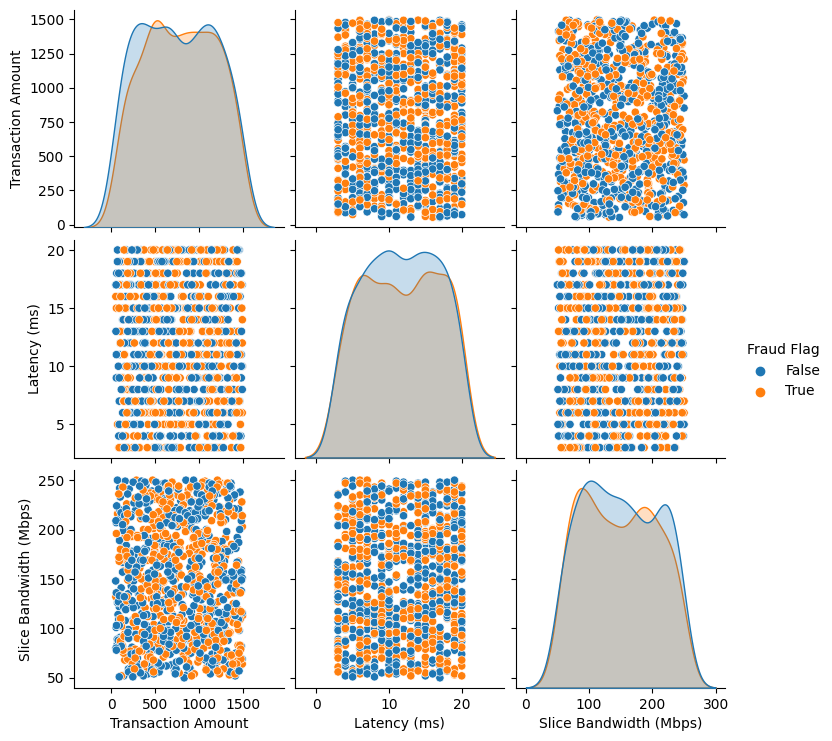

In [19]:
import seaborn as sns
sns.pairplot(analysis_data, hue='Fraud Flag')

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na

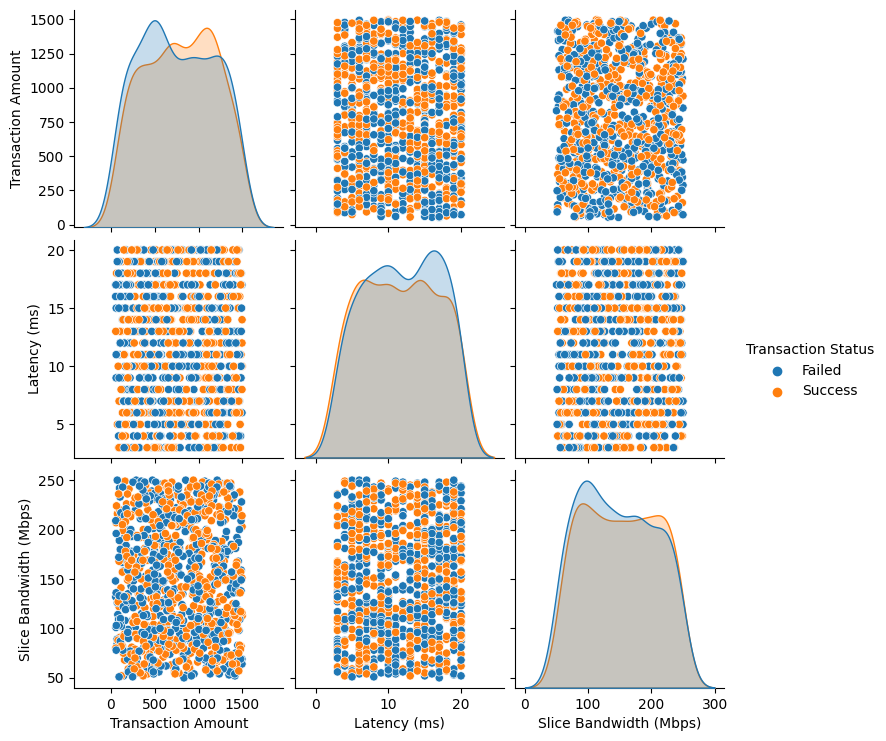

In [20]:
sns.pairplot(analysis_data, hue='Transaction Status')

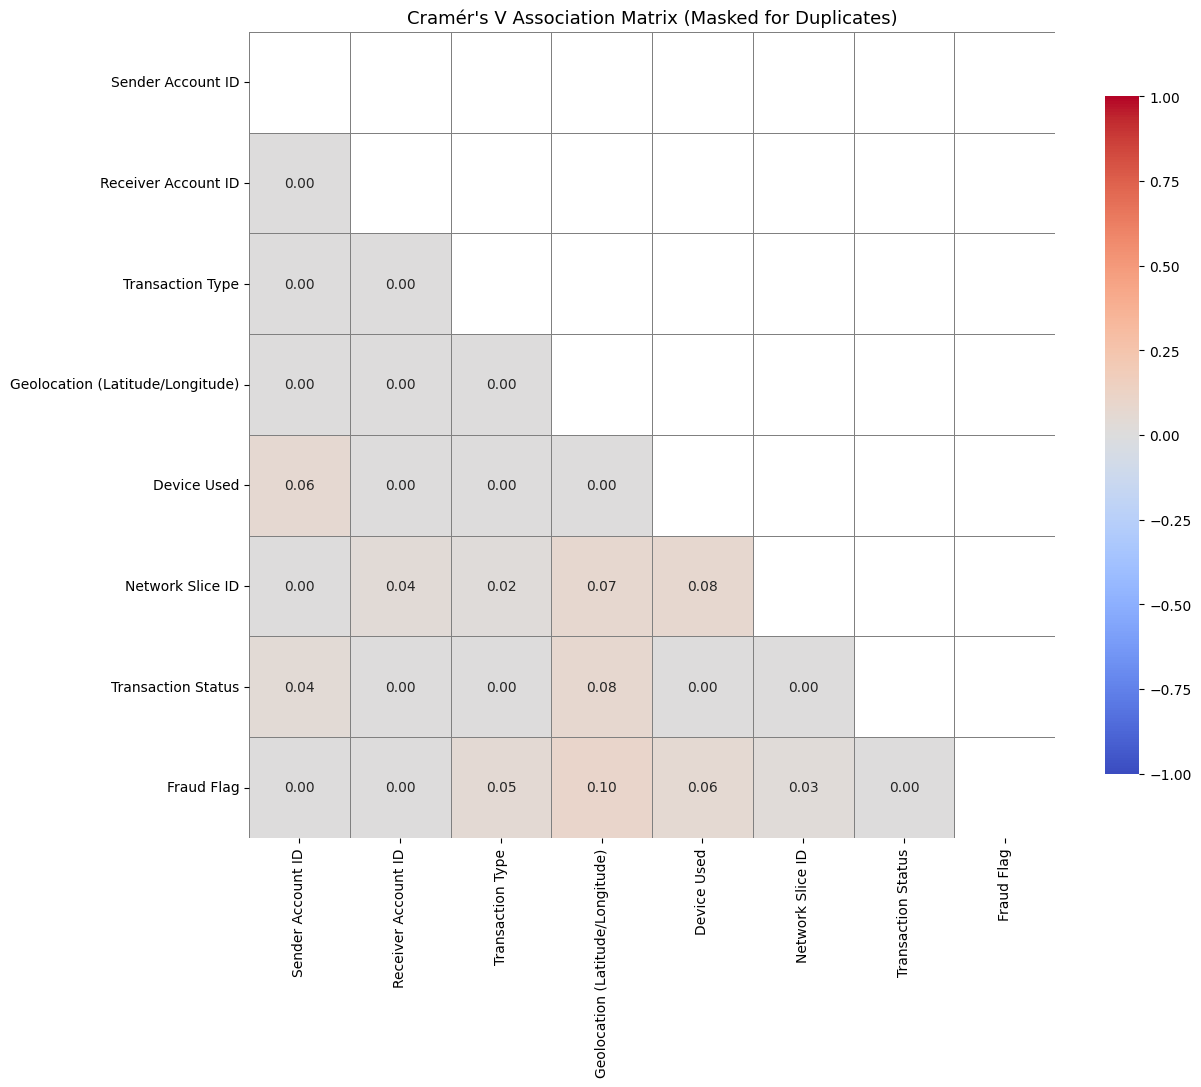

In [21]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import seaborn as sns
import matplotlib.pyplot as plt

# Define the function to calculate Cramér's V
# Reference source: https://www.geeksforgeeks.org/calculate-cramer-s-coefficient-matrix-using-pandas/
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# List of defined categorical columns
categorical_cols

# Create an association matrix to store Cramér's V values
cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

# Calculate Cramér's V for each pair of categorical variables
for i in range(len(categorical_cols)):
    for j in range(len(categorical_cols)):
        if i != j:  # Avoid comparing the same variable
            cramers_v_matrix.iloc[i, j] = cramers_v(analysis_data[categorical_cols[i]], analysis_data[categorical_cols[j]])
        else:
            cramers_v_matrix.iloc[i, j] = 1  # Cramér's V with itself is 1

# Convert the matrix to numeric type
cramers_v_matrix = cramers_v_matrix.astype(float)

# Mask the upper triangle of the matrix to avoid duplication in visualization
# mask = np.tril(np.ones_like(cramers_v_matrix, dtype=bool))
mask = np.triu(np.ones_like(cramers_v_matrix, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(13, 11))

# Create the heatmap with the mask and a color palette
sns.heatmap(cramers_v_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            mask=mask,  # Apply the mask to hide the upper triangle
            square=True,
            cbar_kws={"shrink": .8},
            linewidths=.5,  # Add lines between cells
            linecolor='gray',  # Color of the lines
            vmin=-1, vmax=1)  # Set limits for color scale

# Set title
plt.title("Cramér's V Association Matrix (Masked for Duplicates)", fontsize=13)
plt.show()

Geolocation (Longitude / Latitude) column seem to be showing higher correlation with Network Slice ID, Transaction Status, and Fraud Flag columns.